## EXPLORATION DONNÉES

In [102]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



# Chargement des données

In [103]:
df = pd.read_csv("../data/Most_Streamed_Spotify_Songs_2024.csv", 
                 encoding="utf-8", 
                 encoding_errors="replace")


In [104]:
# 

    # 2. Nettoyage des virgules pour conversion en numérique
colonnes_a_nettoyer = [
        'Spotify Streams', 'Spotify Playlist Count', 'Spotify Playlist Reach', 
        'YouTube Views', 'YouTube Likes', 'TikTok Likes', 'TikTok Views',
        'AirPlay Spins', 'Shazam Counts', 'All Time Rank'
    ]

for col in colonnes_a_nettoyer:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce')
            
    # 3. Suppression des colonnes avec plus de 1000 valeurs nulles
colonnes_vides = df.columns[df.isnull().sum() > 1000]
    
if len(colonnes_vides) > 0:
        print(f" -> Suppression des colonnes suivantes (> 1000 NaN) : {list(colonnes_vides)}")
        df = df.drop(columns=colonnes_vides)

    # 4. Remplacement des valeurs manquantes par la médiane
colonnes_numeriques = df.select_dtypes(include=['float64', 'int64']).columns
    
for col in colonnes_numeriques:
        # Calcul de la médiane en ignorant les valeurs manquantes
        mediane_col = df[col].median()
        # Remplacement des NaN par la médiane trouvée via fillna()
        df[col] = df[col].fillna(mediane_col)

    # 5. Modification du type de la colone "Release Date" en datetime
if 'Release Date' in df.columns:
        df['Release Date'] = pd.to_datetime(df['Release Date'], errors='coerce')
    
    # mettre un underscore à la place des espaces dans les noms de colonnes
df.columns = [col.replace(' ', '_') for col in df.columns]


 -> Suppression des colonnes suivantes (> 1000 NaN) : ['TikTok Posts', 'YouTube Playlist Reach', 'SiriusXM Spins', 'Amazon Playlist Count', 'Pandora Streams', 'Pandora Track Stations', 'Soundcloud Streams', 'TIDAL Popularity']


In [105]:
def summarize(df):

#######   étude statistique   #######

    description = {}

    for colonne in df.columns:
        if pd.api.types.is_numeric_dtype(df[colonne]):
            description[colonne] = {
                'Moyenne': df[colonne].mean().round(2),
                'Médiane': df[colonne].median(),
                'Écart-type': df[colonne].std(),
                'Variance': df[colonne].var(),
                'Minimum': df[colonne].min(),
                'Maximum': df[colonne].max(),
                'Premier quartile (Q1)': df[colonne].quantile(0.25).round(2),
                'Médiane (Q2)': df[colonne].quantile(0.5).round(2),
                'Troisième quartile (Q3)': df[colonne].quantile(0.75).round(2),
                'NAN par colonne': df[colonne].isna().any(),
                'Pourcentage de Nan' : df[colonne].isna().mean()*100,
                'Pourcentage des doublons' : df[colonne].duplicated().mean()*100,
                'Nombre de valeurs uniques': df[colonne].nunique(),
            }
        else:
            description[colonne] = {
                'NAN par colonne': df[colonne].isna().any(),
                'Pourcentage de Nan' : df[colonne].isna().mean() * 100,
                'Nombre de valeurs uniques': df[colonne].nunique()
            }
        df_description = pd.DataFrame(description).T

#######   tableau de corrélation   #######

    df_nb_only = df.select_dtypes(include=['number'])
    df_nb_only_corr = df_nb_only.corr()

    mask = np.triu(np.ones_like(df_nb_only_corr, dtype=bool))

    plt.figure(figsize=(16, 8))
    sns.heatmap(df_nb_only.corr(),mask = mask, annot=True, cmap='RdBu_r',)
    plt.title('tableau de corrélation')
    plt.tight_layout()
    plt.show()

#######   pairplot   #######

    plt.figure(figsize=(16,8))
    if len(df.columns)<=10:
        def lower_triangle(df, **kwargs):
            g = sns.PairGrid(df, **kwargs) #Creer le pairplot
            g= g.map_lower(sns.scatterplot)#Afficher uniquement le triangle inférieur
            g = g.map_diag(sns.histplot)#Garder les histogrammes sur la diagonale
            return g
        lower_triangle(df)
    else :
        print("Trop de colonnes pour un pairplot")





#######   boxplot   #######
    plt.figure(figsize=(16, 8))
    nb_ligne = (len(df_nb_only.columns) // 4) + (len(df_nb_only.columns) % 4 != 0)
    for i, colonne in enumerate(df_nb_only.columns):
        plt.subplot(nb_ligne, 4, i + 1)
        sns.boxplot(data=df_nb_only[colonne], orient='h')
        plt.title(f'Boxplot de {colonne}')
    plt.tight_layout()
    plt.show()


    return df_description.style.background_gradient(axis=None, cmap='YlOrRd',subset=['Pourcentage de Nan','Pourcentage des doublons'])

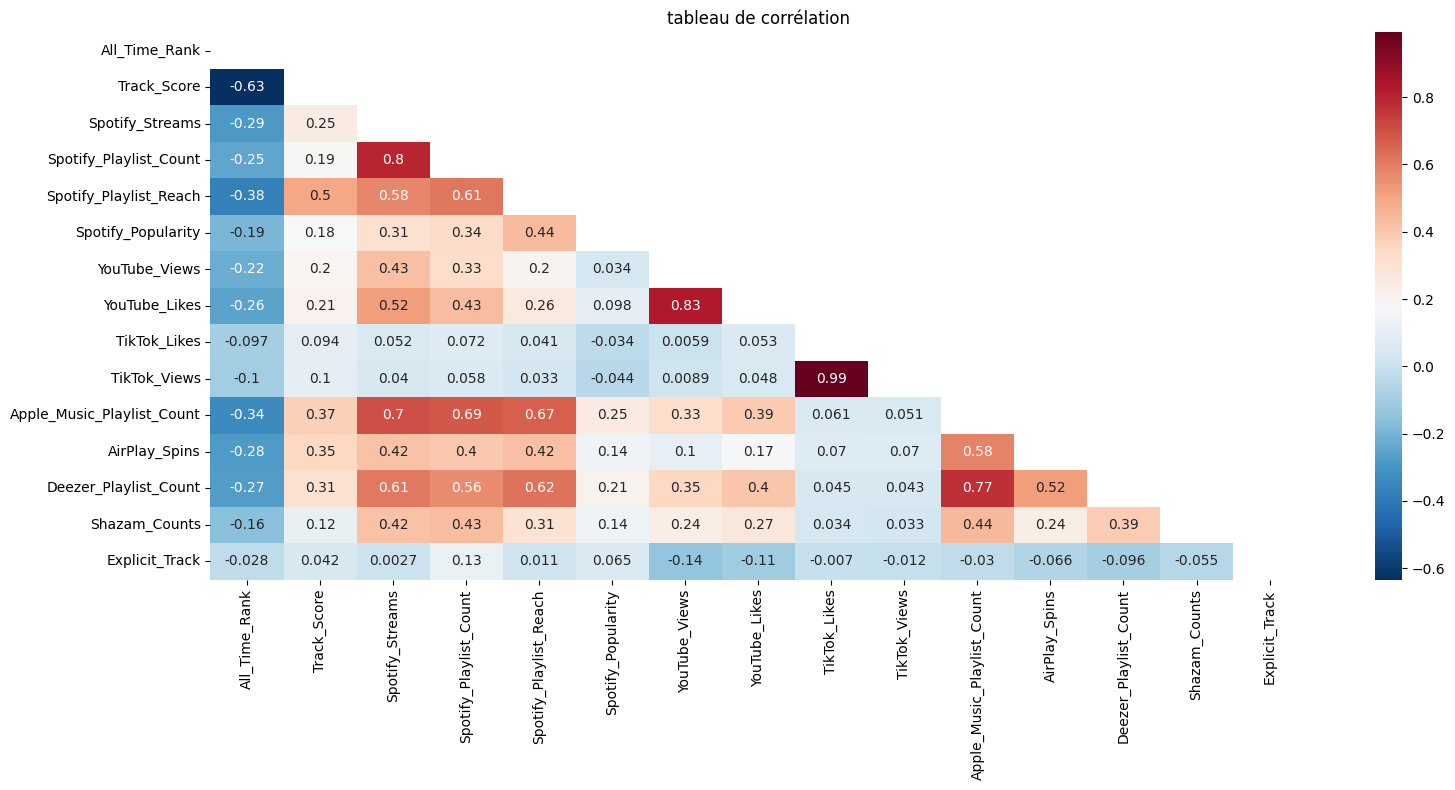

Trop de colonnes pour un pairplot


<Figure size 1600x800 with 0 Axes>

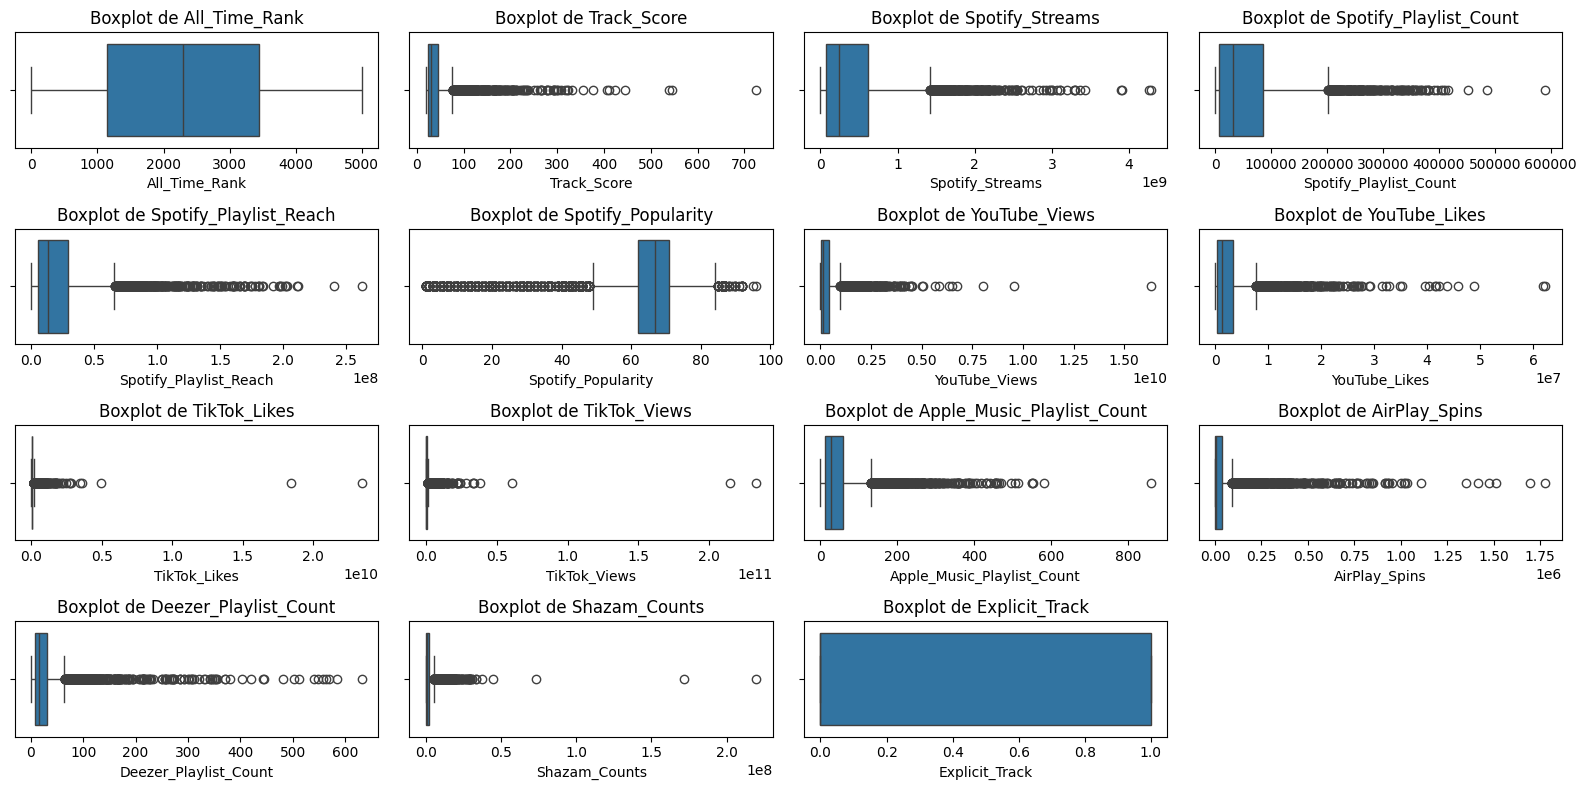

,NAN par colonne,Pourcentage de Nan,Nombre de valeurs uniques,Moyenne,Médiane,Écart-type,Variance,Minimum,Maximum,Premier quartile (Q1),Médiane (Q2),Troisième quartile (Q3),Pourcentage des doublons
Track,False,0.000000,4370,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
Album_Name,False,0.000000,4005,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
Artist,True,0.108696,1999,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
Release_Date,False,0.000000,1562,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
ISRC,False,0.000000,4598,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
All_Time_Rank,False,0.000000,4577,2290.680000,2290.500000,1322.878312,1750007.028959,1,4998,1144.750000,2290.500000,3436.250000,0.500000
Track_Score,False,0.000000,862,41.840000,29.900000,38.543766,1485.621878,19.400000,725.400000,23.300000,29.900000,44.420000,81.260870
Spotify_Streams,False,0.000000,4425,442289133.180000,239850720.000000,532757533.716329,283830589731505696.000000,1071.000000,4281468720.000000,73179221.250000,239850720.000000,611356297.250000,3.804348
Spotify_Playlist_Count,False,0.000000,4208,58978.770000,32312.500000,70665.803007,4993655714.607407,1.000000,590392.000000,7017.750000,32312.500000,84908.250000,8.521739
Spotify_Playlist_Reach,False,0.000000,4479,23188927.330000,13259481.000000,29480475.117403,869098413147824.875000,1.000000,262343414.000000,4906956.250000,13259481.000000,29305264.000000,2.630435


In [106]:
summarize(df)

In [107]:
df.head()

,Track,Album_Name,Artist,Release_Date,ISRC,All_Time_Rank,Track_Score,Spotify_Streams,Spotify_Playlist_Count,Spotify_Playlist_Reach,...,YouTube_Views,YouTube_Likes,TikTok_Likes,TikTok_Views,Apple_Music_Playlist_Count,AirPlay_Spins,Deezer_Playlist_Count,Deezer_Playlist_Reach,Shazam_Counts,Explicit_Track
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,2024-04-26,QM24S2402528,1,725.4,3.904709e+08,30716.0,196631588.0,...,8.427475e+07,1713126.0,6.515659e+08,5.332282e+09,210.0,40975.0,62.0,"17,598,718",2669262.0,0
1,Not Like Us,Not Like Us,Kendrick Lamar,2024-05-04,USUG12400910,2,545.9,3.237039e+08,28113.0,174597137.0,...,1.163470e+08,3486739.0,3.522355e+07,2.083390e+08,188.0,40778.0,67.0,"10,422,430",1118279.0,1
2,i like the way you kiss me,I like the way you kiss me,Artemas,2024-03-19,QZJ842400387,3,538.4,6.013093e+08,54331.0,211607669.0,...,1.225991e+08,2228730.0,2.751542e+08,3.369121e+09,190.0,74333.0,136.0,"36,321,847",5285340.0,0
3,Flowers,Flowers - Single,Miley Cyrus,2023-01-12,USSM12209777,4,444.9,2.031281e+09,269802.0,136569078.0,...,1.096101e+09,10629796.0,1.078758e+09,1.460373e+10,394.0,1474799.0,264.0,"24,684,248",11822942.0,0
4,Houdini,Houdini,Eminem,2024-05-31,USUG12403398,5,423.3,1.070349e+08,7223.0,151469874.0,...,7.737396e+07,3670188.0,2.653441e+07,2.659172e+08,182.0,12185.0,82.0,"17,660,624",457017.0,1


In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Track                       4600 non-null   object        
 1   Album_Name                  4600 non-null   object        
 2   Artist                      4595 non-null   object        
 3   Release_Date                4600 non-null   datetime64[ns]
 4   ISRC                        4600 non-null   object        
 5   All_Time_Rank               4600 non-null   int64         
 6   Track_Score                 4600 non-null   float64       
 7   Spotify_Streams             4600 non-null   float64       
 8   Spotify_Playlist_Count      4600 non-null   float64       
 9   Spotify_Playlist_Reach      4600 non-null   float64       
 10  Spotify_Popularity          4600 non-null   float64       
 11  YouTube_Views               4600 non-null   float64     

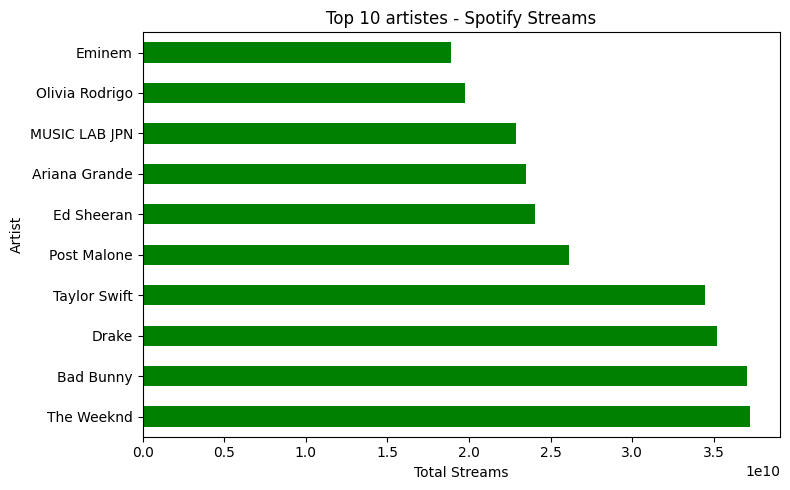

In [134]:
top10 = df.groupby('Artist')['Spotify_Streams'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
top10.plot(kind='barh', color='green')
plt.title('Top 10 artistes - Spotify Streams')
plt.xlabel('Total Streams')
plt.tight_layout()
plt.show()

In [116]:
df_top_artists_streamings_tiktok = df.groupby('Artist')['TikTok_Views'].sum().sort_values(ascending=False).head(10)
print(df_top_artists_streamings_tiktok)

Artist
Kevin MacLeod               2.332323e+11
The King Khan & BBQ Show    2.148440e+11
Kreepa                      6.108856e+10
Doja Cat                    5.432399e+10
Tollan Kim                  4.803314e+10
Bad Bunny                   4.727660e+10
Cavendish Music             3.837364e+10
Kina                        3.513154e+10
Meghan Trainor              3.425879e+10
Taylor Swift                3.374290e+10
Name: TikTok_Views, dtype: float64


In [115]:
ratio_streamings_tiktok = df.groupby('Artist')['Spotify_Streams'].sum() / df.groupby('Artist')['TikTok_Views'].sum()
ratio_streamings_tiktok = ratio_streamings_tiktok.sort_values(ascending=False).head(10)
print(ratio_streamings_tiktok)

Artist
Manu            1.015558e+06
Leo Walrus      4.433470e+05
YSY A           3.823797e+05
KHEA            3.528484e+05
La Vaca Lola    3.210853e+05
Sam Barber      6.284910e+04
Uzielito Mix    1.304627e+04
Angi Fire       1.206263e+04
C��dig          9.987264e+03
daine           2.632482e+03
dtype: float64


In [122]:
df[['Artist', 'Track', 'TikTok_Views', 'Spotify_Streams']].sort_values('Spotify_Streams', ascending=False).head(20)

,Artist,Track,TikTok_Views,Spotify_Streams
55,The Weeknd,Blinding Lights,3.501177e+09,4.281469e+09
4254,xSyborg,Blinding Lights,2.659172e+08,4.261328e+09
53,Ed Sheeran,Shape of You,2.320856e+09,3.909459e+09
1637,xSyborg,Shape of You,2.659172e+08,3.888356e+09
132,Lewis Capaldi,Someone You Loved,2.161032e+09,3.427499e+09
114,Post Malone,Sunflower - Spider-Man: Into the Spider-Verse,1.597454e+09,3.358704e+09
19,Harry Styles,As It Was,1.540588e+10,3.301815e+09
3406,Harry Styles,As It Was,2.659172e+08,3.299082e+09
262,The Weeknd,Starboy,3.754982e+08,3.291262e+09
519,Drake,One Dance,3.885441e+08,3.192204e+09


In [124]:
print(df['TikTok_Views'].corr(df['Spotify_Streams']))

0.03979851843201476


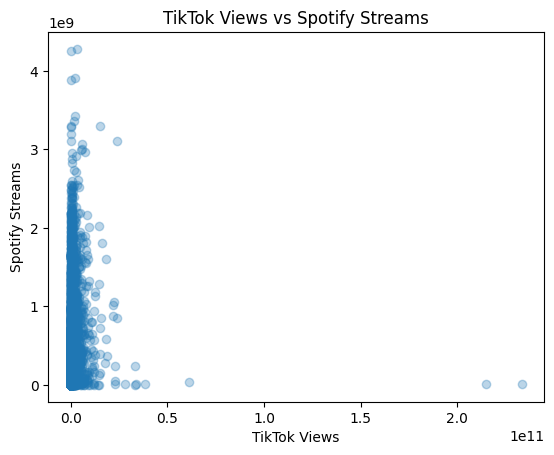

In [123]:
plt.scatter(df['TikTok_Views'], df['Spotify_Streams'], alpha=0.3)
plt.xlabel('TikTok Views')
plt.ylabel('Spotify Streams')
plt.title('TikTok Views vs Spotify Streams')
plt.show()

pas de corrélation entre le nb de stream spotify et le nb de vues tiktok. 

In [126]:
df.columns

Index(['Track', 'Album_Name', 'Artist', 'Release_Date', 'ISRC',
       'All_Time_Rank', 'Track_Score', 'Spotify_Streams',
       'Spotify_Playlist_Count', 'Spotify_Playlist_Reach',
       'Spotify_Popularity', 'YouTube_Views', 'YouTube_Likes', 'TikTok_Likes',
       'TikTok_Views', 'Apple_Music_Playlist_Count', 'AirPlay_Spins',
       'Deezer_Playlist_Count', 'Deezer_Playlist_Reach', 'Shazam_Counts',
       'Explicit_Track'],
      dtype='object')

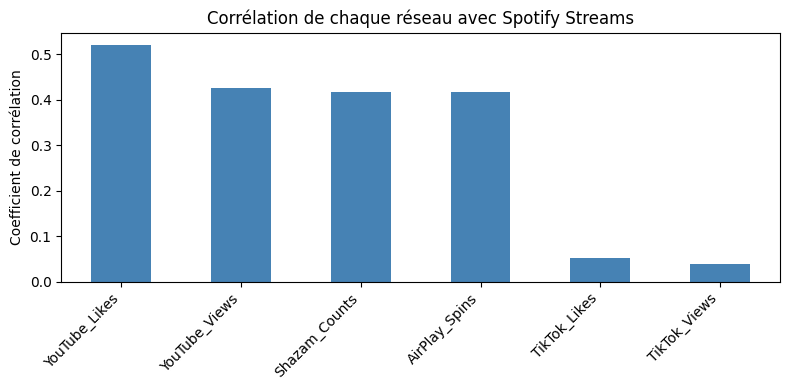

Meilleur prédicteur : YouTube_Likes (0.521)


In [135]:
predicteurs = ['YouTube_Views', 'YouTube_Likes', 'TikTok_Views', 'TikTok_Likes', 'Shazam_Counts', 'AirPlay_Spins']
correlations = df[predicteurs].corrwith(df['Spotify_Streams']).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
correlations.plot(kind='bar', color='steelblue')
plt.title('Corrélation de chaque réseau avec Spotify Streams')
plt.ylabel('Coefficient de corrélation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f'Meilleur prédicteur : {correlations.idxmax()} ({correlations.max():.3f})')